In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
dataset = pd.read_csv('Data/twitchdata-update.csv')
dataset



,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
...,...,...,...,...,...,...,...,...,...,...,...
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English


In [4]:
def descriptive_statistics(sample, field):

    if field not in sample.columns:
        raise ValueError(f"Column '{field}' not found in dataset.")

    data = sample[field].dropna()

    stats_dict = {
        "count": data.count(),
        "mean": data.mean(),
        "median": data.median(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
        "Q1": data.quantile(0.25),
        "Q3": data.quantile(0.75)
    }

    plt.figure(figsize=(8, 6))

    plt.subplot(2, 1, 1)
    plt.hist(data)
    plt.title(f'Histogram of {field}')

    plt.subplot(2, 1, 2)
    plt.boxplot(data, vert=False)
    plt.title(f'Boxplot of {field}')

    plt.tight_layout()

    stats_dict["visualization"] = plt

    return stats_dict


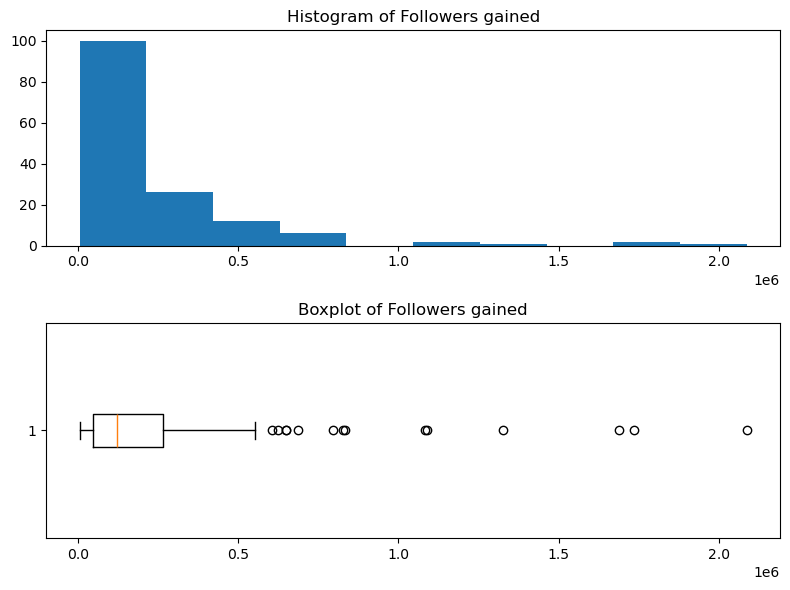

In [8]:
sample_size = 150
N = len(dataset)
k = N // sample_size   # sampling interval

# Start from the first row and select every k-th row
systematic_sample = dataset.iloc[::k].head(sample_size)

# Apply descriptive statistics to dependent variable
# Replace with the exact column name from  dataset
result = descriptive_statistics(systematic_sample, "Followers gained")

In [9]:
print("Systematic Sample Size:", len(systematic_sample))
result


Systematic Sample Size: 150


{'count': np.int64(150),
 'mean': np.float64(230428.36666666667),
 'median': 122244.0,
 'std': 324238.08148045535,
 'min': 6134,
 'max': 2085831,
 'Q1': np.float64(49005.25),
 'Q3': np.float64(266351.75),
 'visualization': <module 'matplotlib.pyplot' from 'C:\\Users\\PC\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>}

In [10]:
result["visualization"].show()